Code for Experiment 5
----------------------

This notebook contains the python code used to analyze the data collected during Experiment 5 of the paper "Building Compressed Causal Models of the World."

In [11]:
#Import all required packages.

import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats

The following block of code imports and cleans the data in the file 'study_5_data.csv'. Be sure that this file is saved in the same folder as your notebook.

In [12]:
data = pd.read_csv('study_5_data.csv')
data=data.drop(labels=0,axis=0) 
data=data.drop(labels=1,axis=0)
exclusions = []
for i in range(2,len(data)):
    if data.CharSel[i] != data.Checker[i] or '995' not in data.CompCheck1[i] or '910' not in data.CompCheck2[i]:
        exclusions = np.append(exclusions,i)
data = data.drop(labels=exclusions,axis=0)
data = data.reset_index()

The following block of code calculates the proportion of participants in the low-information-loss condition, for whom a less compressed representation cost 120 gold coins, who chose the less compressed representation.

In [13]:
count_ll_mv = 0
count_ll_mv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'low' and data.cost[i] == '120':
        count_ll_mv = count_ll_mv + 1
        if data.NoteCardChoice_LL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 100 Gold Coins.':
            count_ll_mv_coarse = count_ll_mv_coarse + 1
[1-count_ll_mv_coarse/count_ll_mv]

[0.2954545454545454]

The following block of code calculates the proportion of participants in the high-information-loss condition, for whom a less compressed representation cost 120 gold coins, who chose the less compressed representation.

In [14]:
count_hl_mv = 0
count_hl_mv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'high' and data.cost[i] == '120':
        count_hl_mv = count_hl_mv + 1
        if data.NoteCardChoice_HL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 100 Gold Coins.':
            count_hl_mv_coarse = count_hl_mv_coarse + 1
[1-count_hl_mv_coarse/count_hl_mv]

[0.6428571428571428]

The following block of code calculates the proportion of participants in the low-information-loss condition, for whom a less compressed representation cost 100 gold coins, who chose the less compressed representation.

In [15]:
count_ll_nv = 0
count_ll_nv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'low' and data.cost[i] == '100':
        count_ll_nv = count_ll_nv + 1
        if data.NoteCardChoice_LL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 100 Gold Coins.':
            count_ll_nv_coarse = count_ll_nv_coarse + 1
[1-count_ll_nv_coarse/count_ll_nv]

[0.8571428571428572]

The following block of code calculates the proportion of participants in the high-information-loss condition, for whom a less compressed representation cost 100 gold coins, who chose the less compressed representation.

In [16]:
count_hl_nv = 0
count_hl_nv_coarse = 0
for i in range(len(data)):
    if data.loss[i] == 'high' and data.cost[i] == '100':
        count_hl_nv = count_hl_nv + 1
        if data.NoteCardChoice_HL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 100 Gold Coins.':
            count_hl_nv_coarse = count_hl_nv_coarse + 1
[1-count_hl_nv_coarse/count_hl_nv]

[0.9130434782608696]

The next block produces the figure showing the main results of the experiment.

/var/folders/09/dm7f60811cqgm3lr35c86qfw0000gn/T/ipykernel_39715/4236742634.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  fig.set_yticklabels(labels=['0','.2','.4','.6','.8','1'],fontsize=30)


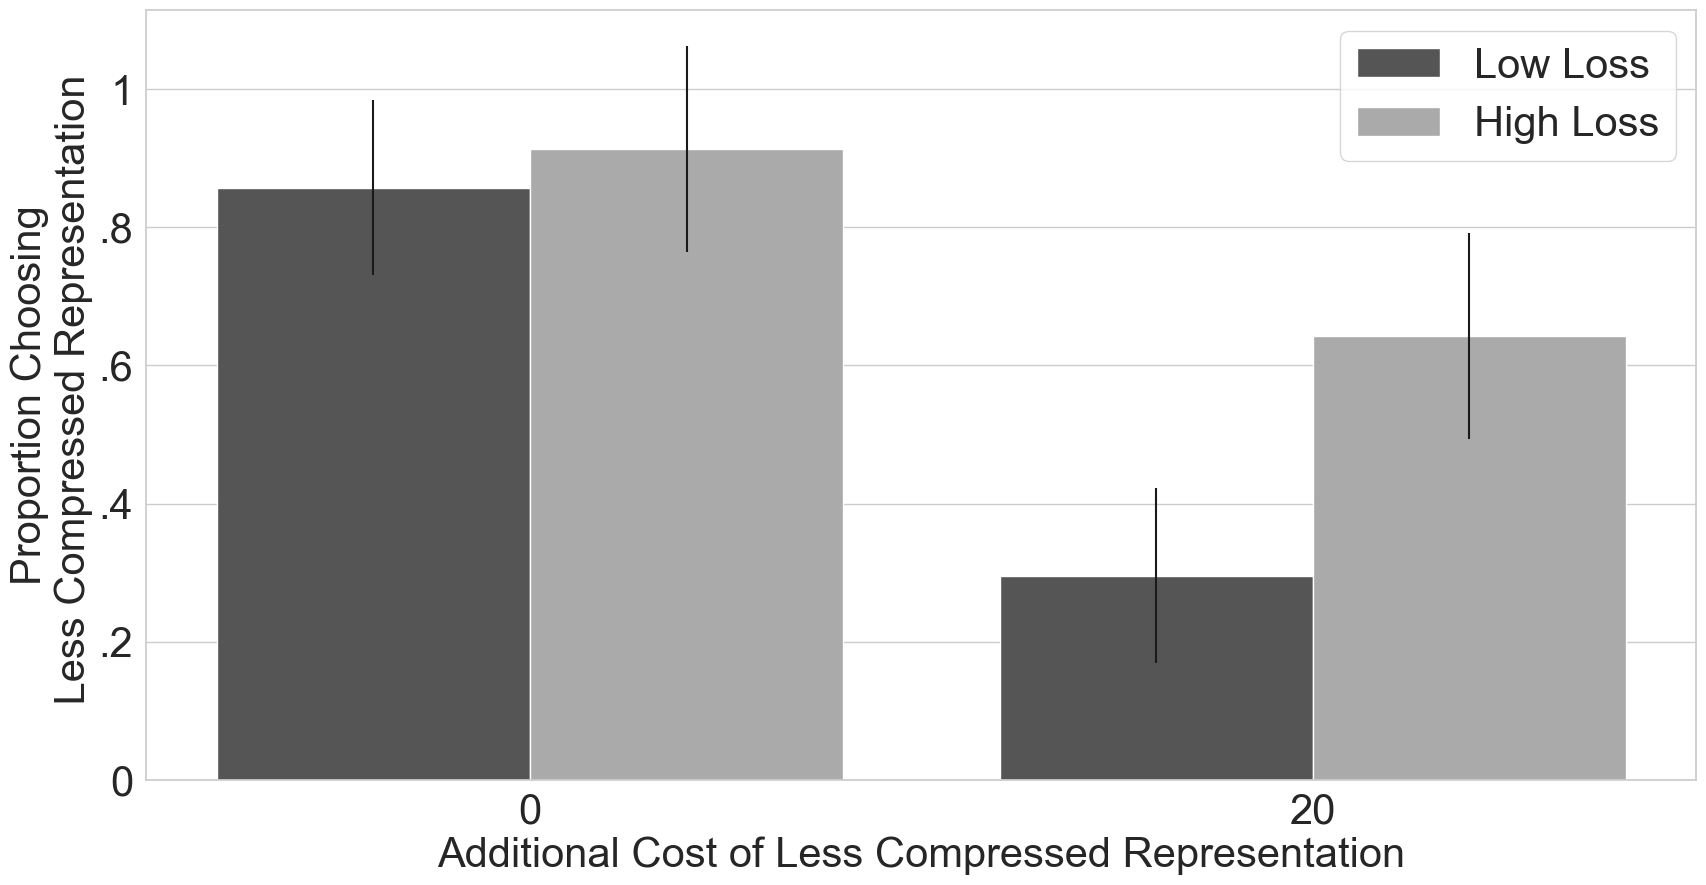

In [17]:
df = pd.DataFrame({'Cost':[0,20],
                   'Low Loss':[1-count_ll_nv_coarse/count_ll_nv,1-count_ll_mv_coarse/count_ll_mv],
                   'High Loss':[1-count_hl_nv_coarse/count_hl_nv,1-count_hl_mv_coarse/count_hl_mv]
})

melted = pd.melt(df, id_vars=['Cost'], value_vars=['Low Loss','High Loss'],var_name='')

def interval(x,arr):
    return 1.96*np.sqrt((x/np.sum([arr]))*((np.sum(arr)-x)/np.sum(arr))/np.sum(arr))

yerr = [interval(count_ll_nv_coarse,[count_ll_nv_coarse,count_ll_mv_coarse]),\
       interval(count_ll_mv_coarse,[count_ll_nv_coarse,count_ll_mv_coarse]),\
       interval(count_hl_nv_coarse,[count_hl_nv_coarse,count_hl_mv_coarse]),\
       interval(count_hl_mv_coarse,[count_hl_nv_coarse,count_hl_mv_coarse])]


sns.set(rc={'figure.figsize':(20,10)})
sns.set_style("whitegrid")
fig = sns.barplot(data=melted,x='Cost',y='value',hue='',palette="gray")
x_coords = [p.get_x() + 0.5*p.get_width() for p in fig.patches]
y_coords = [p.get_height() for p in fig.patches]
plt.errorbar(x=x_coords, y=y_coords, yerr=yerr, fmt="none", c= "k")
fig.set_xlabel('Additional Cost of Less Compressed Representation',fontsize=30)
fig.set_ylabel('Proportion Choosing\n Less Compressed Representation',fontsize=30)
fig.set_xticklabels(labels=['0','20'],fontsize=30)
fig.set_yticklabels(labels=['0','.2','.4','.6','.8','1'],fontsize=30)
plt.legend(fontsize=30)
plt.savefig('Compression By Cost of Fine-Graining and Loss')

The next block performs a binary logistic regression of a variable representing whether the participant chooses the less compressed data representation against the cost of the representation and the amount of information loss inherent in choosing the more compressed representation.

In [18]:
coarse_bin = np.array([0 if data.NoteCardChoice_LL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 100 Gold Coins.'\
              or data.NoteCardChoice_HL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 100 Gold Coins.'\
              else 1 for i in range(len(data))])
cost = np.array([int(data.cost[i])-100 for i in range(len(data))])   
loss = np.array([-1 if data.loss[i] == 'low' else 1 for i in range(len(data))])
cost_loss = np.array([cost[i]*loss[i] for i in range(len(data))])
arr = np.hstack((coarse_bin.reshape(-1,1),cost.reshape(-1,1),loss.reshape(-1,1),cost_loss.reshape(-1,1)))
df = pd.DataFrame(arr,columns = ['Coarse','Cost','Loss','Cost:Loss'])
X = sm.add_constant(df[['Cost','Loss']])
y = df['Coarse']
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.497018
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Coarse   No. Observations:                  202
Model:                          Logit   Df Residuals:                      199
Method:                           MLE   Df Model:                            2
Date:                Thu, 11 May 2023   Pseudo R-squ.:                  0.1991
Time:                        07:25:21   Log-Likelihood:                -100.40
converged:                       True   LL-Null:                       -125.36
Covariance Type:            nonrobust   LLR p-value:                 1.441e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2054      0.326      6.763      0.000       1.566       2.844
Cost          -0.1163      0.

The next block performs a binary logistic regression of a variable representing whether the participant chooses the less compressed data representation against the cost of the representation, the amount of information loss inherent in choosing the more compressed representation, and the interaction between the two.

In [19]:
coarse_bin = np.array([0 if data.NoteCardChoice_LL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 100 Gold Coins.'\
              or data.NoteCardChoice_HL[i] == 'A note card that says "Mushrooms are stronger than flowers." Cost: 100 Gold Coins.'\
              else 1 for i in range(len(data))])
cost = np.array([int(data.cost[i]) for i in range(len(data))])   
loss = np.array([-1 if data.loss[i] == 'low' else 1 for i in range(len(data))])
cost_loss = np.array([cost[i]*loss[i] for i in range(len(data))])
arr = np.hstack((coarse_bin.reshape(-1,1),cost.reshape(-1,1),loss.reshape(-1,1),cost_loss.reshape(-1,1)))
df = pd.DataFrame(arr,columns = ['Coarse','Cost','Loss','Cost:Loss'])
X = sm.add_constant(df[['Cost','Loss','Cost:Loss']])
y = df['Coarse']
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.493869
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Coarse   No. Observations:                  202
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            3
Date:                Thu, 11 May 2023   Pseudo R-squ.:                  0.2042
Time:                        07:25:24   Log-Likelihood:                -99.761
converged:                       True   LL-Null:                       -125.36
Covariance Type:            nonrobust   LLR p-value:                 4.438e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.1325      2.224      5.905      0.000       8.774      17.491
Cost          -0.1106      0.